In [1]:
import numpy as np
import gudhi as gd
import pandas as pd
from sklearn import manifold
from pylab import *
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.tri as mtri
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

Random spread in every direction

c:\Users\Adamc\anaconda3\Lib\site-packages\gudhi\persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

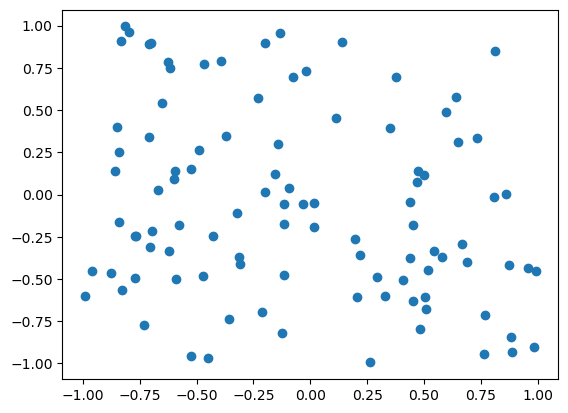

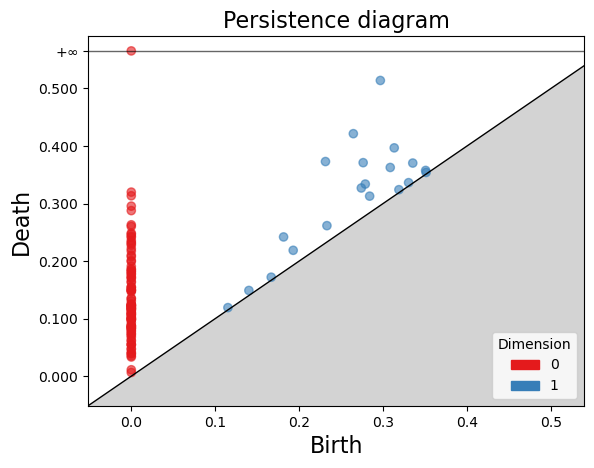

In [2]:
points = np.random.uniform(-1, 1, (100, 2))


srp = gd.RipsComplex(points=points)
st = srp.create_simplex_tree(max_dimension=3)

barcodes_srp=st.persistence()

st.compute_persistence()
plt.scatter(points[:,0], points[:,1])
gd.plot_persistence_diagram(barcodes_srp)


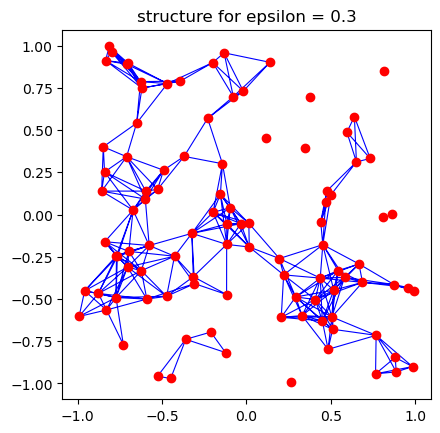

In [22]:
epsilon = 0.3

# Get triangles (3-simplices with filtration <= epsilon)
triangles = np.array([s[0] for s in st.get_skeleton(2) if len(s[0]) == 3 and s[1] <= epsilon])


if len(triangles) > 0:
    triang = mtri.Triangulation(points[:, 0], points[:, 1], triangles)
    plt.triplot(triang, color='blue', lw=0.8)

plt.scatter(points[:, 0], points[:, 1], color='red')
plt.gca().set_aspect('equal')
plt.title(f"structure for epsilon = {epsilon}")
plt.show()

Points in circle

<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

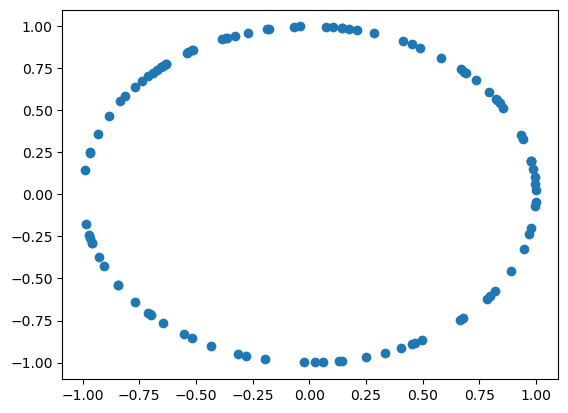

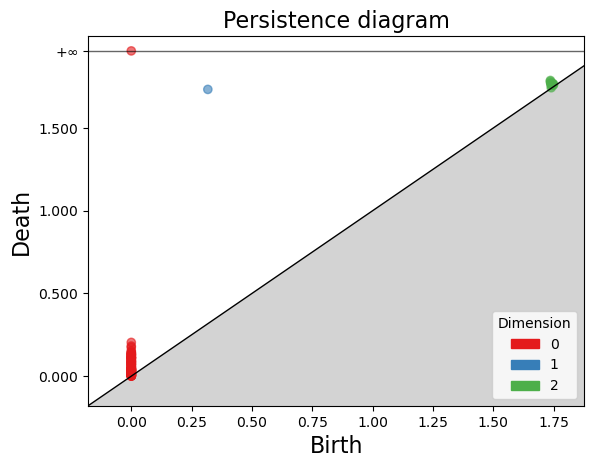

In [6]:
n_points = 100
radius = 1

theta = np.random.uniform(0, 2*np.pi, n_points)
x = radius * np.cos(theta)
y = radius * np.sin(theta)

c_points = np.column_stack((x, y))


crp = gd.RipsComplex(points=c_points)
ct = crp.create_simplex_tree(max_dimension=3)
barcodes_crp=ct.persistence()


plt.scatter(x, y)
gd.plot_persistence_diagram(barcodes_crp)

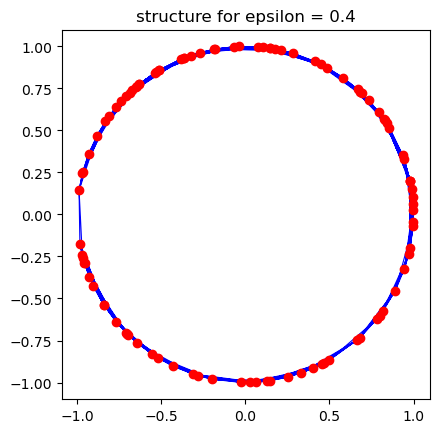

In [ ]:
epsilon_c = 0.4

# Get triangles (3-simplices with filtration <= epsilon)
triangles_c = np.array([c[0] for c in ct.get_skeleton(2) if len(c[0]) == 3 and c[1] <= epsilon_c])


if len(triangles_c) > 0:
    triang_c = mtri.Triangulation(c_points[:, 0], c_points[:, 1], triangles_c)
    plt.triplot(triang_c, color='blue', lw=0.8)

plt.scatter(c_points[:, 0], c_points[:, 1], color='red')
plt.gca().set_aspect('equal')
plt.title(f"structure for epsilon = {epsilon_c}")
plt.show()

Pregenerated data

<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

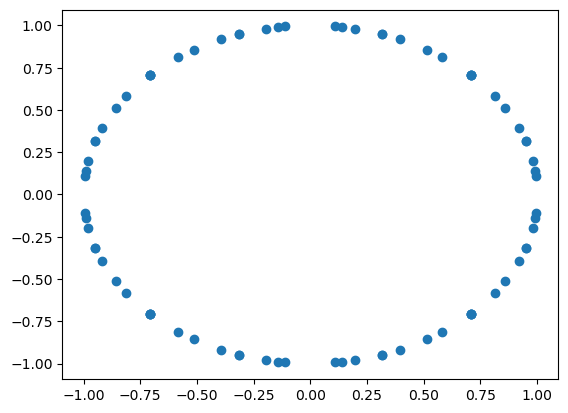

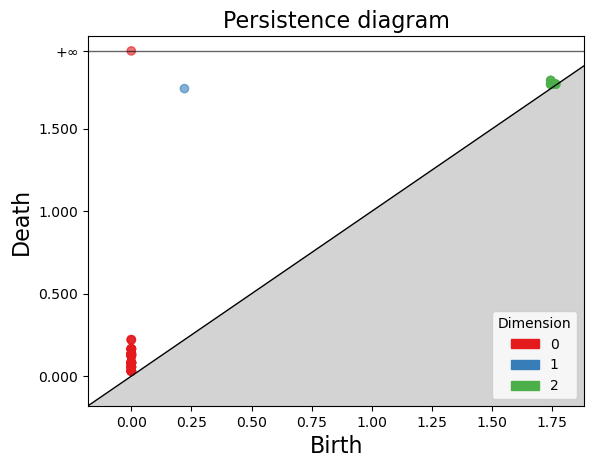

In [47]:
points_i = np.loadtxt("data/points/sphere2D_80.off", skiprows=2)


ip = gd.RipsComplex(points=points_i)
it = ip.create_simplex_tree(max_dimension=3)

barcodes_ip=it.persistence()

it.compute_persistence()
plt.scatter(points_i[:,0], points_i[:,1])
gd.plot_persistence_diagram(barcodes_ip)

Random data streched by eigenvalues

<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

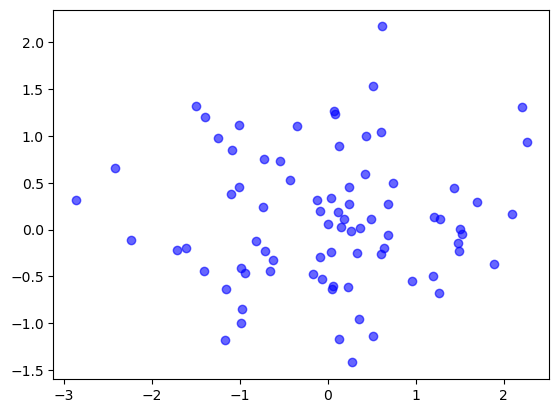

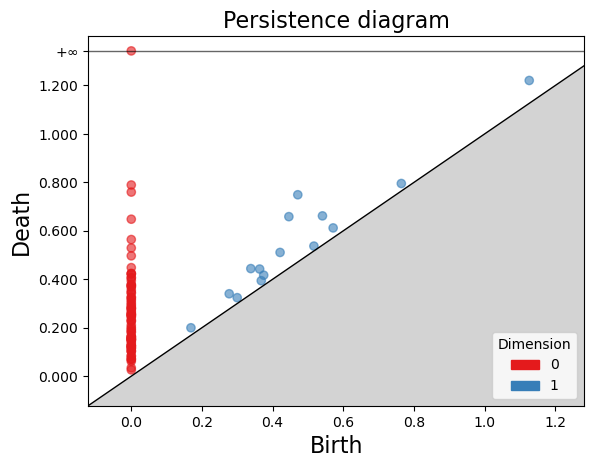

In [73]:
num_points = 80
n=2

A = np.random.randn(n, n)
eigenvalues = abs(np.linalg.eigvals(A) )
Q, _ = np.linalg.qr(A)
sy_points = np.random.randn(num_points, 2)
sy_points = sy_points @ Q @ np.diag(np.sqrt(eigenvalues))


syp = gd.RipsComplex(points=sy_points)
syt = syp.create_simplex_tree(max_dimension=3)

barcodes_syp=syt.persistence()

it.compute_persistence()



plt.scatter(sy_points[:,0], sy_points[:,1], color='blue', alpha=0.6)
gd.plot_persistence_diagram(barcodes_syp)

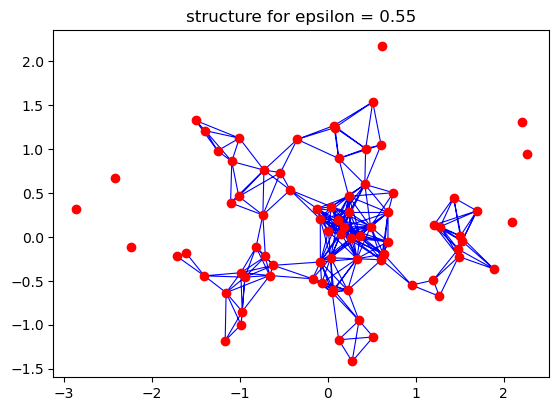

In [75]:
epsilon_sy = 0.55

# Get triangles (3-simplices with filtration <= epsilon)
triangles_sy = np.array([sy[0] for sy in syt.get_skeleton(2) if len(sy[0]) == 3 and sy[1] <= epsilon_sy])


if len(triangles_sy) > 0:
    triang_sy = mtri.Triangulation(sy_points[:, 0], sy_points[:, 1], triangles_sy)
    plt.triplot(triang_sy, color='blue', lw=0.8)

plt.scatter(sy_points[:, 0], sy_points[:, 1], color='red')
plt.gca().set_aspect('equal')
plt.title(f"structure for epsilon = {epsilon_sy}")
plt.show()

c:\Users\Adamc\anaconda3\Lib\site-packages\gudhi\persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

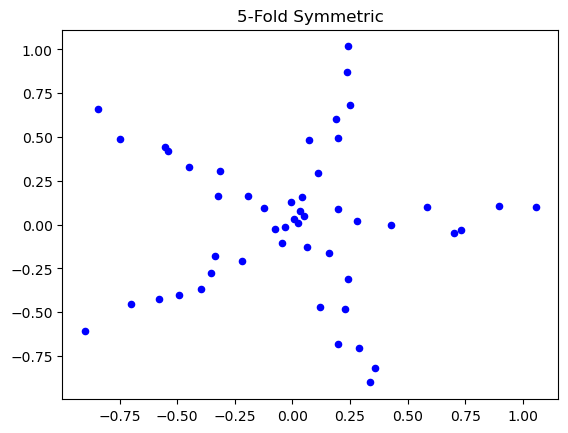

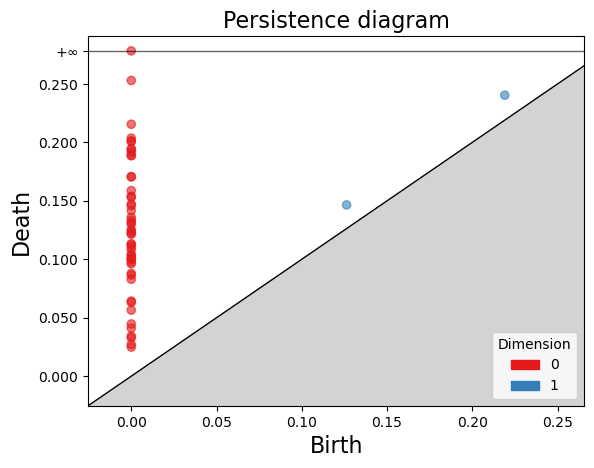

In [2]:
num_points_per_arm=10
radius=1.0
noise=0.05
points_shape = []
angles = np.linspace(0, radius, num_points_per_arm)
for k in range(5):
    theta_offset = k * (2 * np.pi / 5) 
    for r in angles:
        x = r * np.cos(theta_offset) + np.random.normal(0, noise)
        y = r * np.sin(theta_offset) + np.random.normal(0, noise)
        points_shape.append([x, y])
points_shape=np.array(points_shape)



p_shape = gd.RipsComplex(points=points_shape)
shapet = p_shape.create_simplex_tree(max_dimension=3)

barcodes_p_shape=shapet.persistence()

shapet.compute_persistence()





plt.scatter(points_shape[:,0], points_shape[:,1], s=20, color='blue')
plt.title("5-Fold Symmetric")
gd.plot_persistence_diagram(barcodes_p_shape)

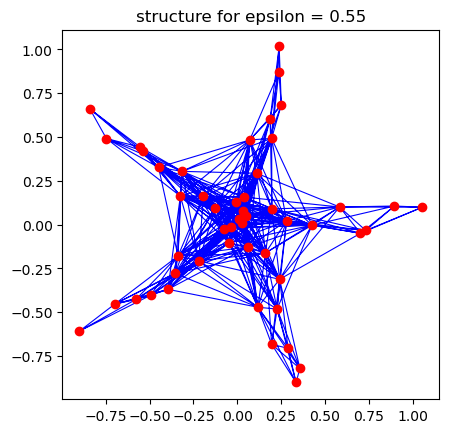

In [4]:
epsilon_shape = 0.55

# Get triangles (3-simplices with filtration <= epsilon)
triangles_shape = np.array([sh[0] for sh in shapet.get_skeleton(2) if len(sh[0]) == 3 and sh[1] <= epsilon_shape])


if len(triangles_shape) > 0:
    triang_shape = mtri.Triangulation(points_shape[:, 0], points_shape[:, 1], triangles_shape)
    plt.triplot(triang_shape, color='blue', lw=0.8)

plt.scatter(points_shape[:, 0], points_shape[:, 1], color='red')
plt.gca().set_aspect('equal')
plt.title(f"structure for epsilon = {epsilon_shape}")
plt.show()

In [84]:
#circle vs circle
Ic0=ct.persistence_intervals_in_dimension(0)
Ii0=it.persistence_intervals_in_dimension(0)

Ic1=ct.persistence_intervals_in_dimension(1)
Ii1=it.persistence_intervals_in_dimension(1)

print(gd.bottleneck_distance(Ic0,Ii0))
print(gd.bottleneck_distance(Ic1,Ii1))
print("")

#square vs eigen
Is0=st.persistence_intervals_in_dimension(0)
Isy0=syt.persistence_intervals_in_dimension(0)

Is1=st.persistence_intervals_in_dimension(1)
Isy1=syt.persistence_intervals_in_dimension(1)

print(gd.bottleneck_distance(Is0,Isy0))
print(gd.bottleneck_distance(Is1,Isy1))

0.047395286172195766
0.09626181748611207

0.3944784861303384
0.1387661385105159
